In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/nyc_taxi_trip_duration.csv")

print(data.head())
print(data.shape)

          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id1080784          2  2016-02-29 16:40:21  2016-02-29 16:47:01   
1  id0889885          1  2016-03-11 23:35:37  2016-03-11 23:53:57   
2  id0857912          2  2016-02-21 17:59:33  2016-02-21 18:26:48   
3  id3744273          2  2016-01-05 09:44:31  2016-01-05 10:03:32   
4  id0232939          1  2016-02-17 06:42:23  2016-02-17 06:56:31   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0              1.0        -73.953918        40.778873         -73.963875   
1              2.0        -73.988312        40.731743         -73.994751   
2              2.0        -73.997314        40.721458         -73.948029   
3              6.0        -73.961670        40.759720         -73.956779   
4              1.0        -74.017120        40.708469         -73.988182   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.771164                  N          400.0  
1         40.694

In [2]:
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])

data = data[(data['trip_duration'] > 60) & (data['trip_duration'] < 7200)]

data = data[(data['pickup_longitude'] > -75) & (data['pickup_longitude'] < -73)]
data = data[(data['pickup_latitude'] > 40) & (data['pickup_latitude'] < 42)]

print("Dataset après nettoyage:", data.shape)

Dataset après nettoyage: (54423, 11)


In [3]:

data['hour'] = data['pickup_datetime'].dt.hour
data['day_of_week'] = data['pickup_datetime'].dt.dayofweek
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)


data['period_of_day'] = pd.cut(
    data['hour'],
    bins=[-1, 6, 9, 17, 20, 23],
    labels=['Nuit', 'Matin tôt', 'Pointe', 'Soir', 'Nuit tardive'])

In [4]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a)) * 1000

data['distance_m'] = haversine(
    data.pickup_longitude.values,
    data.pickup_latitude.values,
    data.dropoff_longitude.values,
    data.dropoff_latitude.values)

In [5]:
data['pickup_zone'] = pd.cut(
    data['pickup_latitude'],
    bins=[40.6, 40.7, 40.75, 40.9],
    labels=['Sud', 'Centre', 'Nord'])

In [6]:
data['speed_kmh'] = (data['distance_m'] / 1000) / (data['trip_duration'] / 3600)

/tmp/ipykernel_6470/2400286703.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_stats = data.groupby('period_of_day')['trip_duration'].mean()/60
/tmp/ipykernel_6470/2400286703.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_stats = data.groupby('pickup_zone')['trip_duration'].mean()/60


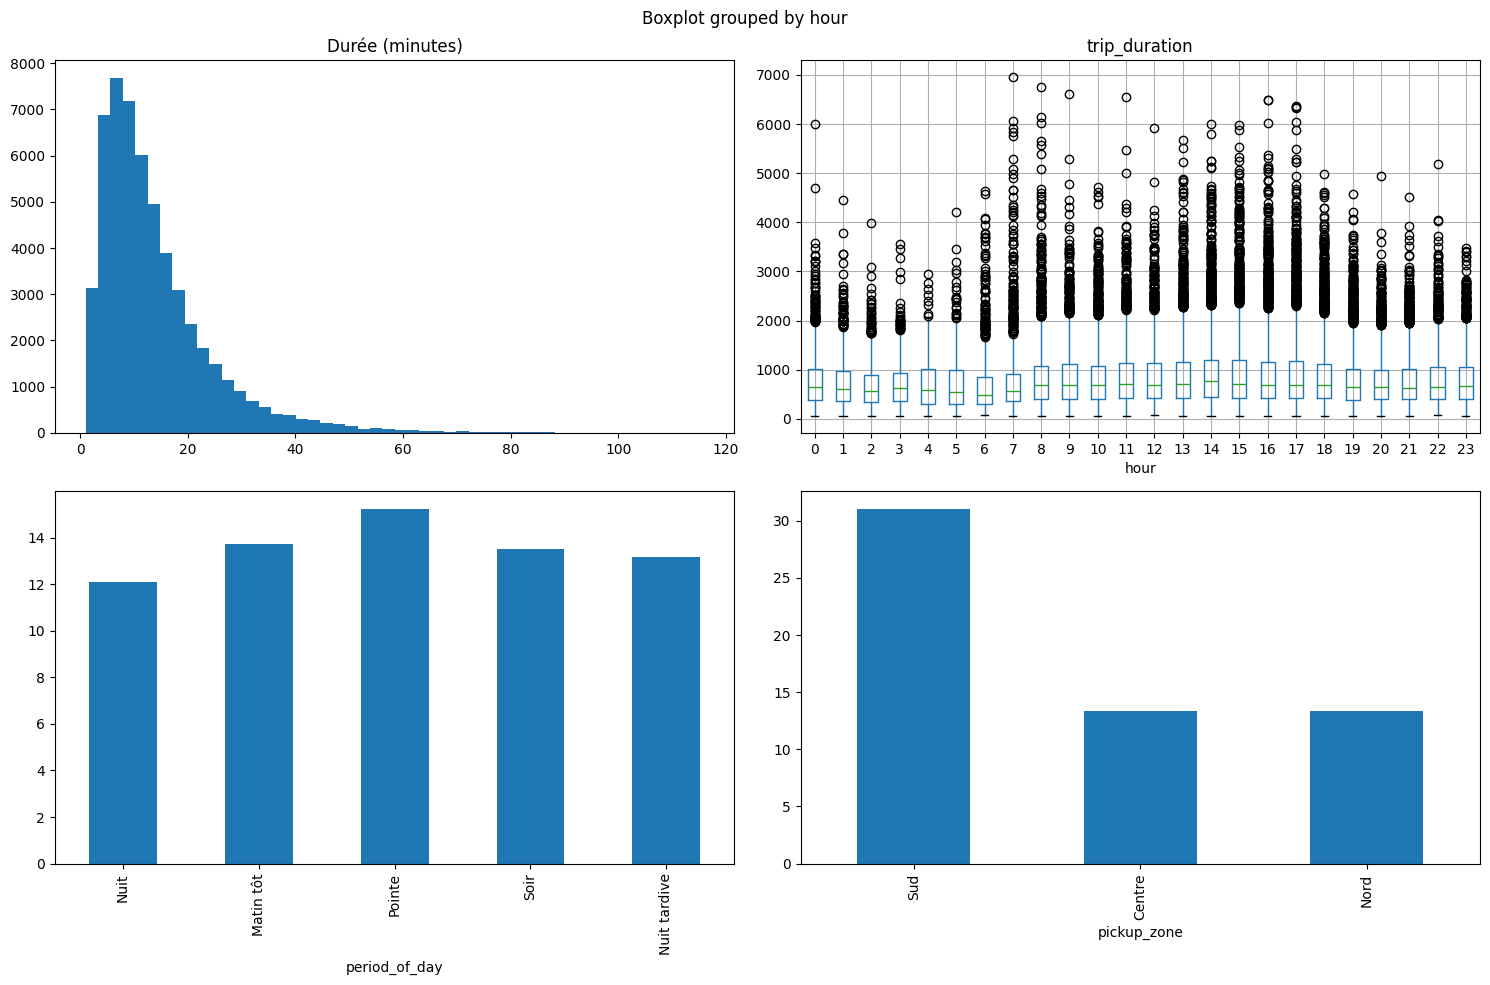

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


axes[0,0].hist(data['trip_duration']/60, bins=50)
axes[0,0].set_title('Durée (minutes)')

data.boxplot(column='trip_duration', by='hour', ax=axes[0,1])

period_stats = data.groupby('period_of_day')['trip_duration'].mean()/60
period_stats.plot(kind='bar', ax=axes[1,0])


zone_stats = data.groupby('pickup_zone')['trip_duration'].mean()/60
zone_stats.plot(kind='bar', ax=axes[1,1])

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

groups = [group['trip_duration'].dropna().values
          for name, group in data.groupby('hour')]


f_stat, p_value = stats.f_oneway(*groups)

print("test:")
print(f"F = {f_stat:.2f}, p = {p_value:.5f}")


print("Levene:", stats.levene(*groups))

test:
F = 35.37, p = 0.00000
Levene: LeveneResult(statistic=np.float64(29.66550529377987), pvalue=np.float64(1.7320903120099564e-128))


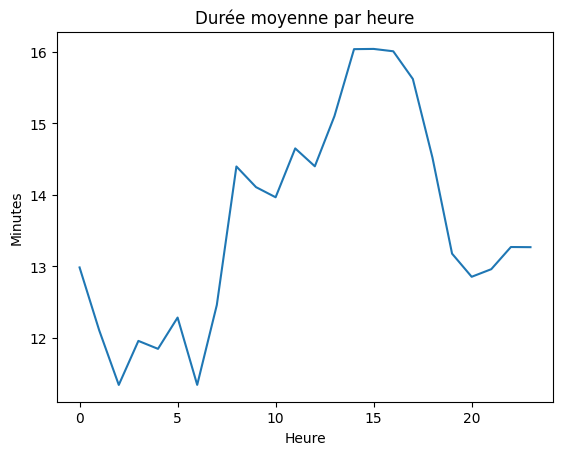

In [9]:
hourly = data.groupby('hour')['trip_duration'].mean()/60

plt.plot(hourly.index, hourly.values)
plt.title("Durée moyenne par heure")
plt.xlabel("Heure")
plt.ylabel("Minutes")
plt.show()

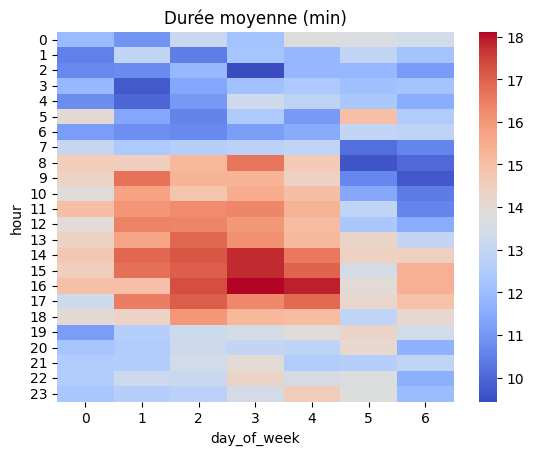

In [10]:
pivot = data.pivot_table(values='trip_duration',
                         index='hour',
                         columns='day_of_week',
                         aggfunc='mean')

sns.heatmap(pivot/60, cmap='coolwarm')
plt.title("Durée moyenne (min)")
plt.show()


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


features = ['hour', 'day_of_week', 'is_weekend', 'distance_m']


ml_data = data[features + ['trip_duration']].dropna()

X = ml_data[features]
y = ml_data['trip_duration']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestRegressor(n_estimators=100, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Résultats du modèle :")
print(f"MAE (erreur moyenne) : {mae:.2f} secondes")
print(f"R² (qualité du modèle) : {r2:.3f}")

Résultats du modèle :
MAE (erreur moyenne) : 258.94 secondes
R² (qualité du modèle) : 0.646


In [12]:
peak_hours = hourly.nlargest(3)

print("Interpretation finale:")
print(f"Variation significative ? {'OUI' if p_value < 0.05 else 'NON'}")
print("Heures de pointe:", list(peak_hours.index))
print("Variabilité:", data['trip_duration'].std()/60)
print("Zone congestionnée:", zone_stats.idxmax())

Interpretation finale:
Variation significative ? OUI
Heures de pointe: [15, 14, 16]
Variabilité: 10.832484637451204
Zone congestionnée: Sud
